# AAL Sales Analysis — Q4 2020

**Company:** Australian Apparel Limited (AAL)  
**Dataset:** `AusApparalSales4thQrt2020.csv`  
**Author:** Data Science Team  
**Date:** April 2026  

---

## Objective

Analyse AAL's fourth-quarter 2020 sales data on a state-by-state basis to help the CEO and the head of Sales & Marketing (S&M) make data-driven investment and expansion decisions for the upcoming year.

The analysis covers four key stages:
1. **Data Wrangling** – cleaning, missing-value treatment, normalisation, GroupBy insights  
2. **Data Analysis** – descriptive statistics, group rankings, weekly / monthly / quarterly summaries  
3. **Data Visualisation** – dashboards for S&M stakeholders  
4. **Report Generation** – findings and recommendations in Markdown

---
## 0. Setup – Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('seaborn:', sns.__version__)

pandas : 3.0.2
numpy  : 2.4.4
seaborn: 0.13.2


---
## 1. Data Wrangling

### 1.1 Load the Raw Data

In [2]:
df_raw = pd.read_csv('AusApparalSales4thQrt2020.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (7560, 6)


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
5,1-Oct-2020,Afternoon,WA,Men,10,25000
6,1-Oct-2020,Afternoon,WA,Women,3,7500
7,1-Oct-2020,Afternoon,WA,Seniors,11,27500
8,1-Oct-2020,Evening,WA,Kids,15,37500
9,1-Oct-2020,Evening,WA,Men,15,37500


In [3]:
# Overview
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


### 1.2 Clean Column Names & Whitespace

In [4]:
df = df_raw.copy()

# Strip leading/trailing whitespace from all string columns
df.columns = df.columns.str.strip()
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

df.head(5)

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


### 1.3 Parse Dates & Engineer Time Features

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')
df['Week']    = df['Date'].dt.isocalendar().week.astype(int)
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayName'] = df['Date'].dt.day_name()

# Ordered category for Time-of-day
time_order = ['Morning', 'Afternoon', 'Evening']
df['Time'] = pd.Categorical(df['Time'], categories=time_order, ordered=True)

print(df.dtypes)
df.head()

Date       datetime64[us]
Time             category
State                 str
Group                 str
Unit                int64
Sales               int64
Week                int64
Month               int32
Quarter             int32
DayName               str
dtype: object


,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter,DayName
0,2020-10-01,Morning,WA,Kids,8,20000,40,10,4,Thursday
1,2020-10-01,Morning,WA,Men,8,20000,40,10,4,Thursday
2,2020-10-01,Morning,WA,Women,4,10000,40,10,4,Thursday
3,2020-10-01,Morning,WA,Seniors,15,37500,40,10,4,Thursday
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,10,4,Thursday


### 1.4 Missing & Incorrect Value Inspection

In [6]:
print('=== isna() count per column ===')
print(df.isna().sum())

print('\n=== notna() count per column ===')
print(df.notna().sum())

=== isna() count per column ===
Date       0
Time       0
State      0
Group      0
Unit       0
Sales      0
Week       0
Month      0
Quarter    0
DayName    0
dtype: int64

=== notna() count per column ===
Date       7560
Time       7560
State      7560
Group      7560
Unit       7560
Sales      7560
Week       7560
Month      7560
Quarter    7560
DayName    7560
dtype: int64


In [7]:
print('Negative or zero Units:', (df['Unit'] <= 0).sum())
print('Negative or zero Sales:', (df['Sales'] <= 0).sum())
print('\nUnique States :', sorted(df['State'].unique()))
print('Unique Groups  :', sorted(df['Group'].unique()))
print('Unique Times   :', list(df['Time'].cat.categories))

Negative or zero Units: 0
Negative or zero Sales: 0

Unique States : ['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
Unique Groups  : ['Kids', 'Men', 'Seniors', 'Women']
Unique Times   : ['Morning', 'Afternoon', 'Evening']


**Finding:** The dataset is complete — no missing values and no negative or zero entries. All categorical values are consistent.

> **Recommendation:** Because the data is already clean we do not need to drop or impute any rows. Should future loads contain `NaN` values in numeric columns the recommended approach is **median imputation** (median is robust to outliers); for categorical columns use **mode imputation** or a dedicated `'Unknown'` category. Rows with missing key identifiers (State, Group) should be dropped.

### 1.5 Normalisation

**Choice: Min-Max Normalisation**  
Min-Max scaling maps each numeric column to the range [0, 1]. It is preferred here because:
- The sales figures do not follow a Gaussian distribution (they vary widely by state/group), so Z-score standardisation would not centre a meaningful distribution.
- Stakeholder dashboards benefit from values between 0 and 1 for easy interpretation of relative performance.
- All values are positive — no sign issues with the transformation.

In [8]:
from sklearn.preprocessing import MinMaxScaler   # available via scikit-learn

scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[['Unit_norm', 'Sales_norm']] = scaler.fit_transform(df[['Unit', 'Sales']])

print('Normalised columns (first 5 rows):')
df_norm[['Date', 'State', 'Group', 'Unit', 'Unit_norm', 'Sales', 'Sales_norm']].head()

Normalised columns (first 5 rows):


,Date,State,Group,Unit,Unit_norm,Sales,Sales_norm
0,2020-10-01,WA,Kids,8,0.095238,20000,0.095238
1,2020-10-01,WA,Men,8,0.095238,20000,0.095238
2,2020-10-01,WA,Women,4,0.031746,10000,0.031746
3,2020-10-01,WA,Seniors,15,0.206349,37500,0.206349
4,2020-10-01,WA,Kids,3,0.015873,7500,0.015873


> **Note:** The normalised columns (`Unit_norm`, `Sales_norm`) are kept for visualisation and model-readiness but all descriptive statistics and business reports below use the original `Unit` and `Sales` columns for interpretability.

### 1.6 GroupBy — Chunking vs. Merging

Pandas `GroupBy` can be used for two distinct purposes:

| Mode | Description | When to use |
|------|-------------|-------------|
| **Chunking** (`groupby(...).apply()`) | Split the DataFrame into independent sub-DataFrames, process each chunk separately, then collect results. | When per-group transformations differ (e.g., group-specific normalisation, custom aggregations). |
| **Merging** (`groupby(...).agg()` / `.transform()`) | Aggregate or broadcast group-level summaries back to the original index. | When you need a single summary table or want to add group-level columns back to every row. |

**Recommendation for this project:** Use `groupby(...).agg()` for summary tables (merging mode) — it produces clean pivot-ready DataFrames. Use `groupby(...).transform()` when adding a group-level statistic (e.g., group mean) as a new column for each row.

In [9]:
# Example – group-mean Sales added back to every row (merging / transform)
df['Group_Mean_Sales'] = df.groupby('Group')['Sales'].transform('mean')
df[['Date', 'State', 'Group', 'Sales', 'Group_Mean_Sales']].head(8)

,Date,State,Group,Sales,Group_Mean_Sales
0,2020-10-01,WA,Kids,20000,45011.904762
1,2020-10-01,WA,Men,20000,45370.370370
2,2020-10-01,WA,Women,10000,45207.671958
3,2020-10-01,WA,Seniors,37500,44464.285714
4,2020-10-01,WA,Kids,7500,45011.904762
5,2020-10-01,WA,Men,25000,45370.370370
6,2020-10-01,WA,Women,7500,45207.671958
7,2020-10-01,WA,Seniors,27500,44464.285714


---
## 2. Data Analysis

### 2.1 Descriptive Statistics — Sales & Unit Columns

In [10]:
desc_cols = ['Unit', 'Sales']

desc = df[desc_cols].agg(['mean', 'median', 'std', 'min', 'max'])
desc.loc['mode'] = [df['Unit'].mode()[0], df['Sales'].mode()[0]]
desc

,Unit,Sales
mean,18.005423,45013.558201
median,14.000000,35000.000000
std,12.901403,32253.506944
min,2.000000,5000.000000
max,65.000000,162500.000000
mode,9.000000,22500.000000


In [11]:
# Full describe() for reference
df[desc_cols].describe().round(2)

,Unit,Sales
count,7560.00,7560.00
mean,18.01,45013.56
std,12.90,32253.51
min,2.00,5000.00
25%,8.00,20000.00
50%,14.00,35000.00
75%,26.00,65000.00
max,65.00,162500.00


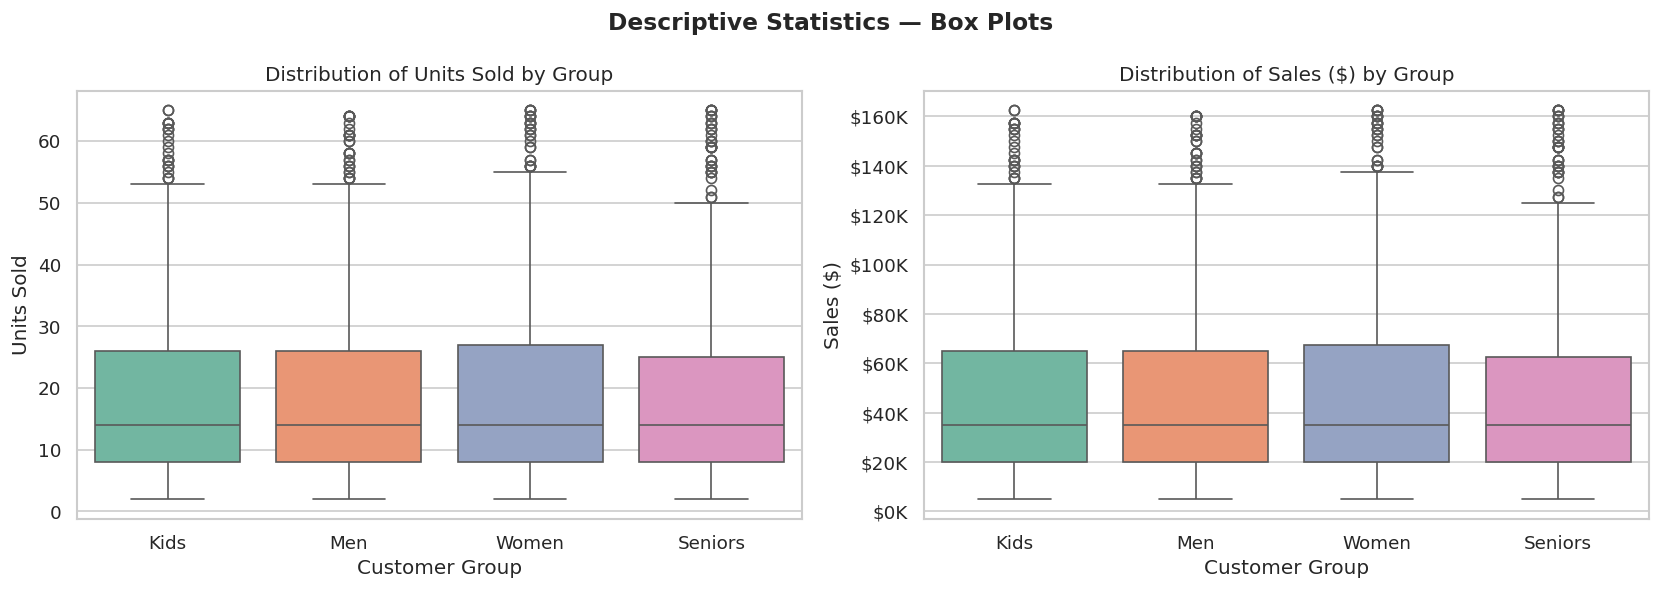

In [12]:
# Box plots for descriptive statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Group', y='Unit', palette='Set2', ax=axes[0])
axes[0].set_title('Distribution of Units Sold by Group')
axes[0].set_xlabel('Customer Group')
axes[0].set_ylabel('Units Sold')

sns.boxplot(data=df, x='Group', y='Sales', palette='Set2', ax=axes[1])
axes[1].set_title('Distribution of Sales ($) by Group')
axes[1].set_xlabel('Customer Group')
axes[1].set_ylabel('Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Descriptive Statistics — Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Group Rankings — Highest & Lowest Sales

In [13]:
group_sales = df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print('Total Sales by Group (descending):')
print(group_sales.apply(lambda x: f'${x:,.0f}'))
print(f'\nHighest sales group : {group_sales.idxmax()}  (${group_sales.max():,.0f})')
print(f'Lowest sales group  : {group_sales.idxmin()}  (${group_sales.min():,.0f})')

Total Sales by Group (descending):
Group
Men        $85,750,000
Women      $85,442,500
Kids       $85,072,500
Seniors    $84,037,500
Name: Sales, dtype: str

Highest sales group : Men  ($85,750,000)
Lowest sales group  : Seniors  ($84,037,500)


In [14]:
# State rankings
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print('Total Sales by State (descending):')
print(state_sales.apply(lambda x: f'${x:,.0f}'))
print(f'\nHighest revenue state : {state_sales.idxmax()}  (${state_sales.max():,.0f})')
print(f'Lowest revenue state  : {state_sales.idxmin()}  (${state_sales.min():,.0f})')

Total Sales by State (descending):
State
VIC    $105,565,000
NSW     $74,970,000
SA      $58,857,500
QLD     $33,417,500
TAS     $22,760,000
NT      $22,580,000
WA      $22,152,500
Name: Sales, dtype: str

Highest revenue state : VIC  ($105,565,000)
Lowest revenue state  : WA  ($22,152,500)


### 2.3 Weekly Report

In [15]:
weekly = (
    df.groupby('Week')
    .agg(Total_Units=('Unit', 'sum'), Total_Sales=('Sales', 'sum'), Transactions=('Sales', 'count'))
    .reset_index()
)
weekly['Avg_Sales_per_Txn'] = (weekly['Total_Sales'] / weekly['Transactions']).round(2)
weekly['Total_Sales_fmt'] = weekly['Total_Sales'].apply(lambda x: f'${x:,.0f}')
print('=== Weekly Sales Report ===')
weekly[['Week', 'Total_Units', 'Total_Sales_fmt', 'Transactions', 'Avg_Sales_per_Txn']]

=== Weekly Sales Report ===


,Week,Total_Units,Total_Sales_fmt,Transactions,Avg_Sales_per_Txn
0,40,6018,"$15,045,000",336,44776.79
1,41,10801,"$27,002,500",588,45922.62
2,42,10656,"$26,640,000",588,45306.12
3,43,10726,"$26,815,000",588,45603.74
4,44,8723,"$21,807,500",504,43268.85
5,45,8346,"$20,865,000",588,35484.69
6,46,8469,"$21,172,500",588,36007.65
7,47,8445,"$21,112,500",588,35905.61
8,48,8591,"$21,477,500",588,36526.36
9,49,11849,"$29,622,500",588,50378.40


### 2.4 Monthly Report

In [16]:
month_map = {10: 'October', 11: 'November', 12: 'December'}

monthly = (
    df.groupby('Month')
    .agg(Total_Units=('Unit', 'sum'), Total_Sales=('Sales', 'sum'), Transactions=('Sales', 'count'))
    .reset_index()
)
monthly['Month_Name'] = monthly['Month'].map(month_map)
monthly['Total_Sales_fmt'] = monthly['Total_Sales'].apply(lambda x: f'${x:,.0f}')
print('=== Monthly Sales Report ===')
monthly[['Month_Name', 'Total_Units', 'Total_Sales_fmt', 'Transactions']]

=== Monthly Sales Report ===


,Month_Name,Total_Units,Total_Sales_fmt,Transactions
0,October,45716,"$114,290,000",2520
1,November,36273,"$90,682,500",2520
2,December,54132,"$135,330,000",2520


### 2.5 Quarterly Report

In [17]:
quarterly = (
    df.groupby('Quarter')
    .agg(Total_Units=('Unit', 'sum'), Total_Sales=('Sales', 'sum'), Transactions=('Sales', 'count'))
    .reset_index()
)
quarterly['Total_Sales_fmt'] = quarterly['Total_Sales'].apply(lambda x: f'${x:,.0f}')
print('=== Quarterly Sales Report ===')
quarterly[['Quarter', 'Total_Units', 'Total_Sales_fmt', 'Transactions']]

=== Quarterly Sales Report ===


,Quarter,Total_Units,Total_Sales_fmt,Transactions
0,4,136121,"$340,302,500",7560


---
## 3. Data Visualisation

**Visualisation Library: Seaborn**  
Seaborn is built on Matplotlib and tightly integrated with Pandas DataFrames. It is preferred for statistical analysis because:
- It produces publication-quality charts with sensible defaults.
- It natively supports categorical and aggregation plots (`barplot`, `boxplot`, `heatmap`).
- The `FacetGrid` and `catplot` APIs make faceted dashboards straightforward to build.
- Distribution plots (`histplot`, `kdeplot`, `displot`) integrate statistical overlays out-of-the-box.

### 3.1 State-Wise Sales by Demographic Group

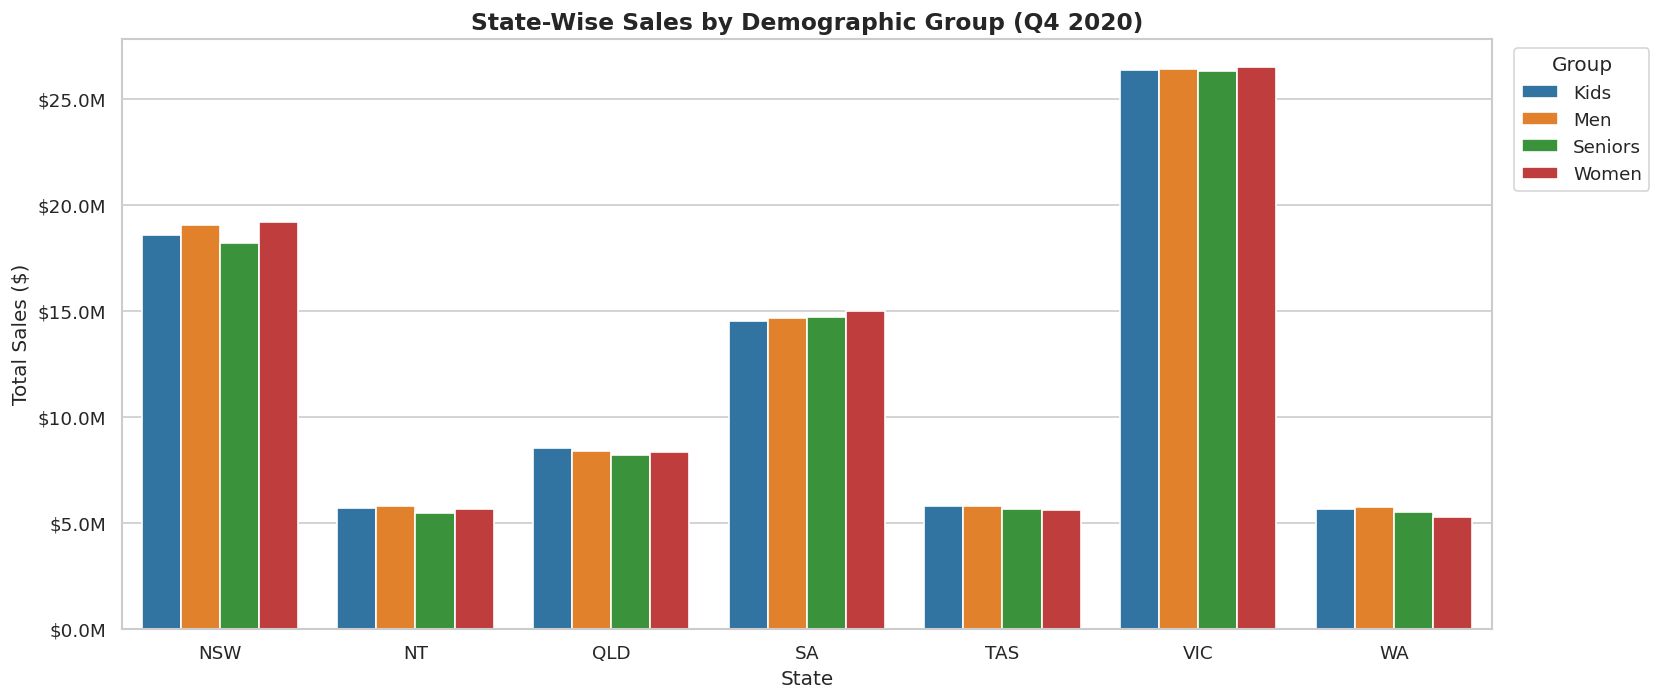

In [18]:
state_group = df.groupby(['State', 'Group'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=state_group, x='State', y='Sales', hue='Group', palette='tab10', ax=ax)
ax.set_title('State-Wise Sales by Demographic Group (Q4 2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.2 Group-Wise Sales Across States

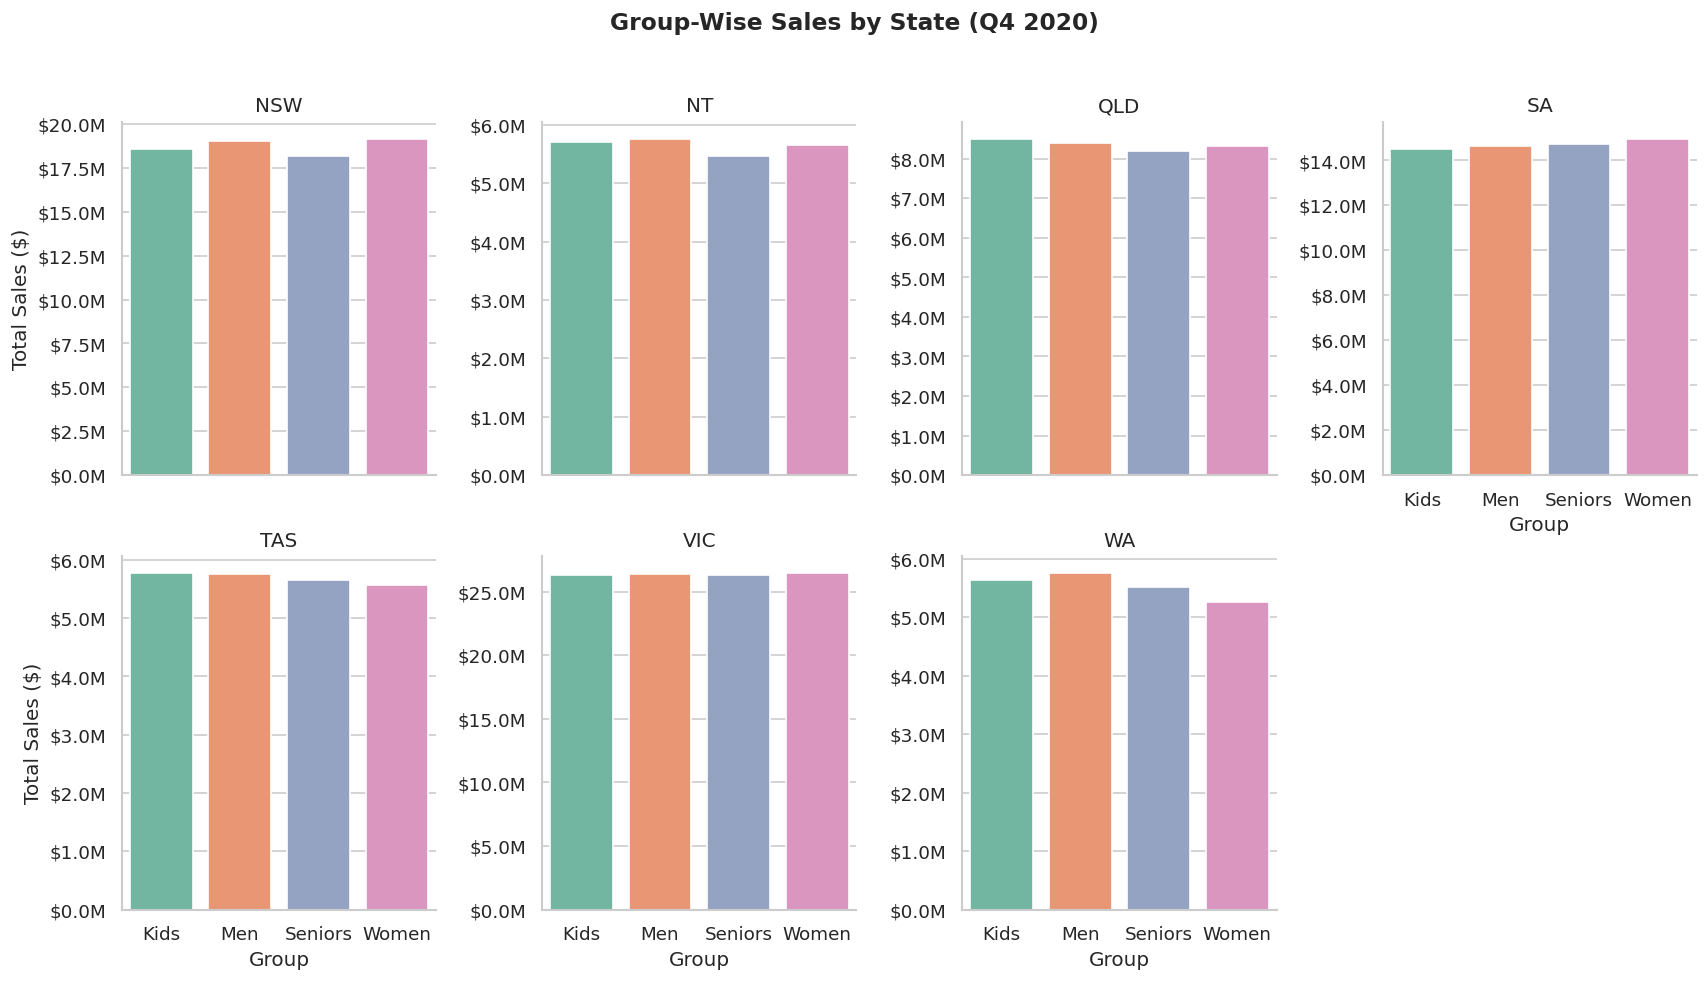

In [19]:
g = sns.catplot(
    data=state_group, kind='bar',
    x='Group', y='Sales', col='State',
    col_wrap=4, height=4, aspect=0.9,
    palette='Set2', sharey=False
)
g.set_titles('{col_name}')
g.set_axis_labels('Group', 'Total Sales ($)')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
g.figure.suptitle('Group-Wise Sales by State (Q4 2020)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Time-of-Day Analysis (Peak vs Off-Peak)

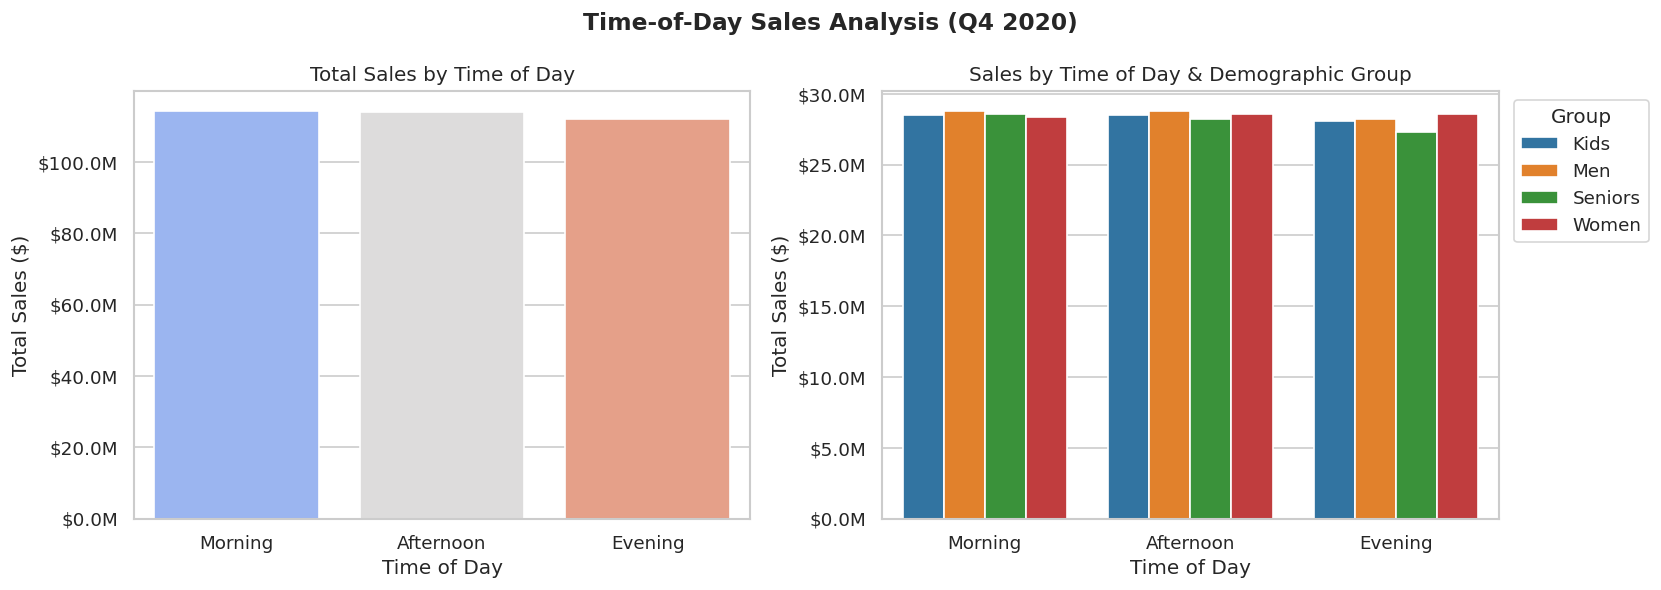

In [20]:
tod_sales = df.groupby(['Time'])['Sales'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall time-of-day
sns.barplot(data=tod_sales, x='Time', y='Sales', palette='coolwarm', order=time_order, ax=axes[0])
axes[0].set_title('Total Sales by Time of Day')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Time-of-day by Group
tod_group = df.groupby(['Time', 'Group'])['Sales'].sum().reset_index()
sns.barplot(data=tod_group, x='Time', y='Sales', hue='Group', palette='tab10',
            order=time_order, ax=axes[1])
axes[1].set_title('Sales by Time of Day & Demographic Group')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Total Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].legend(title='Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Time-of-Day Sales Analysis (Q4 2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Daily Sales Trend

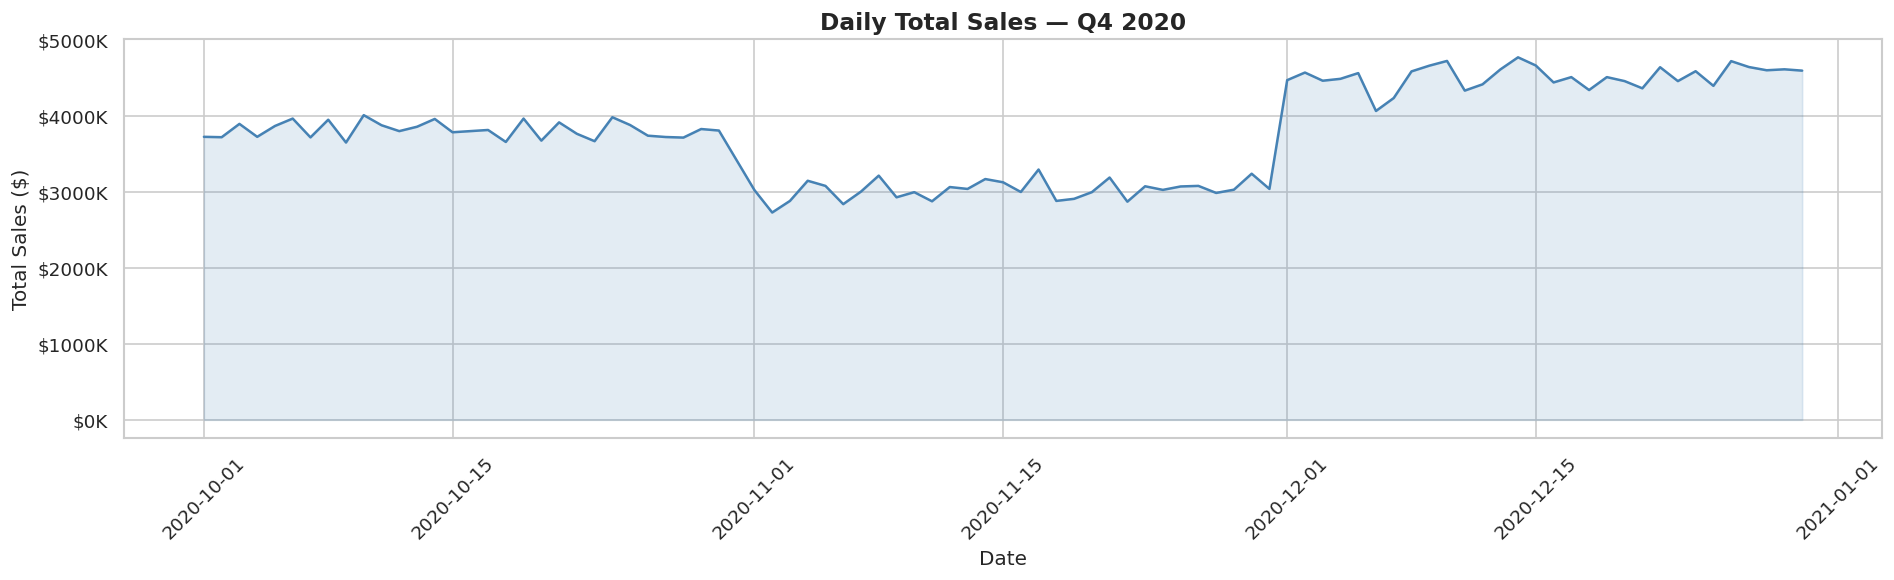

In [21]:
daily = df.groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=daily, x='Date', y='Sales', color='steelblue', linewidth=1.5, ax=ax)
ax.fill_between(daily['Date'], daily['Sales'], alpha=0.15, color='steelblue')
ax.set_title('Daily Total Sales — Q4 2020', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Weekly Sales Trend

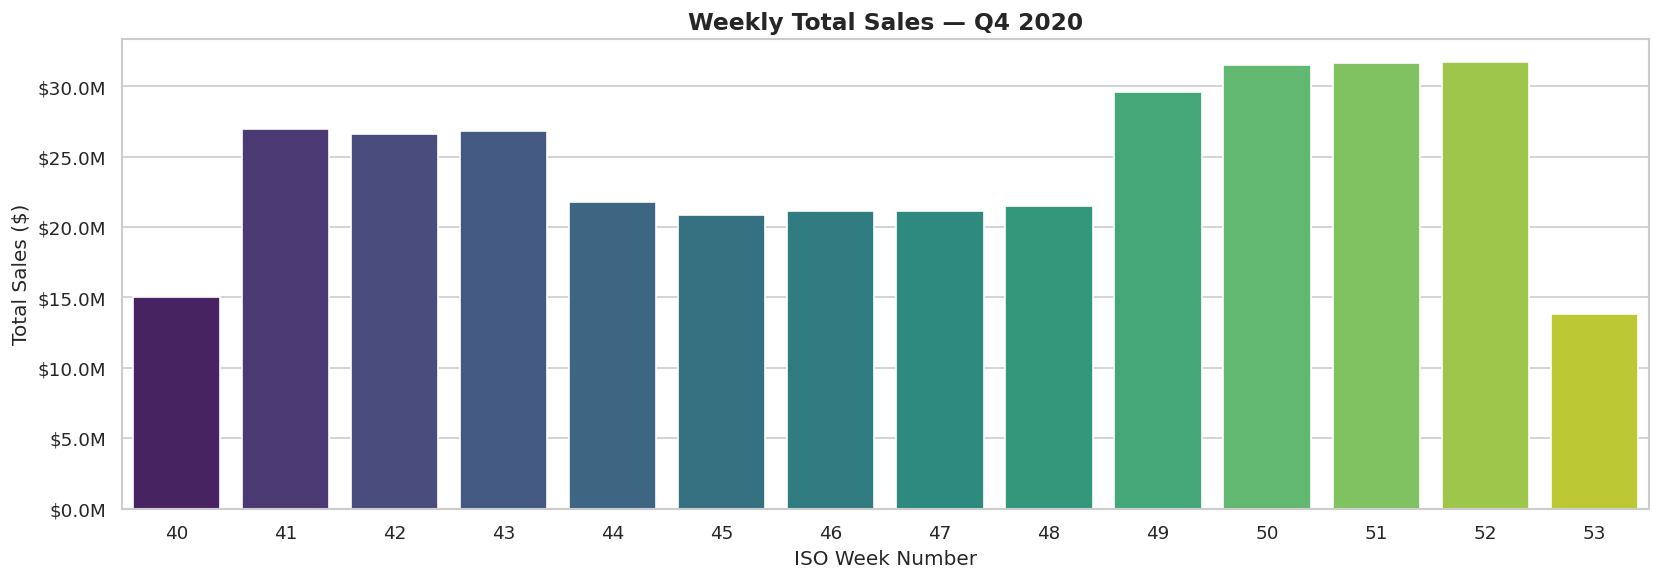

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=weekly, x='Week', y='Total_Sales', palette='viridis', ax=ax)
ax.set_title('Weekly Total Sales — Q4 2020', fontsize=14, fontweight='bold')
ax.set_xlabel('ISO Week Number')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### 3.6 Monthly Sales Comparison

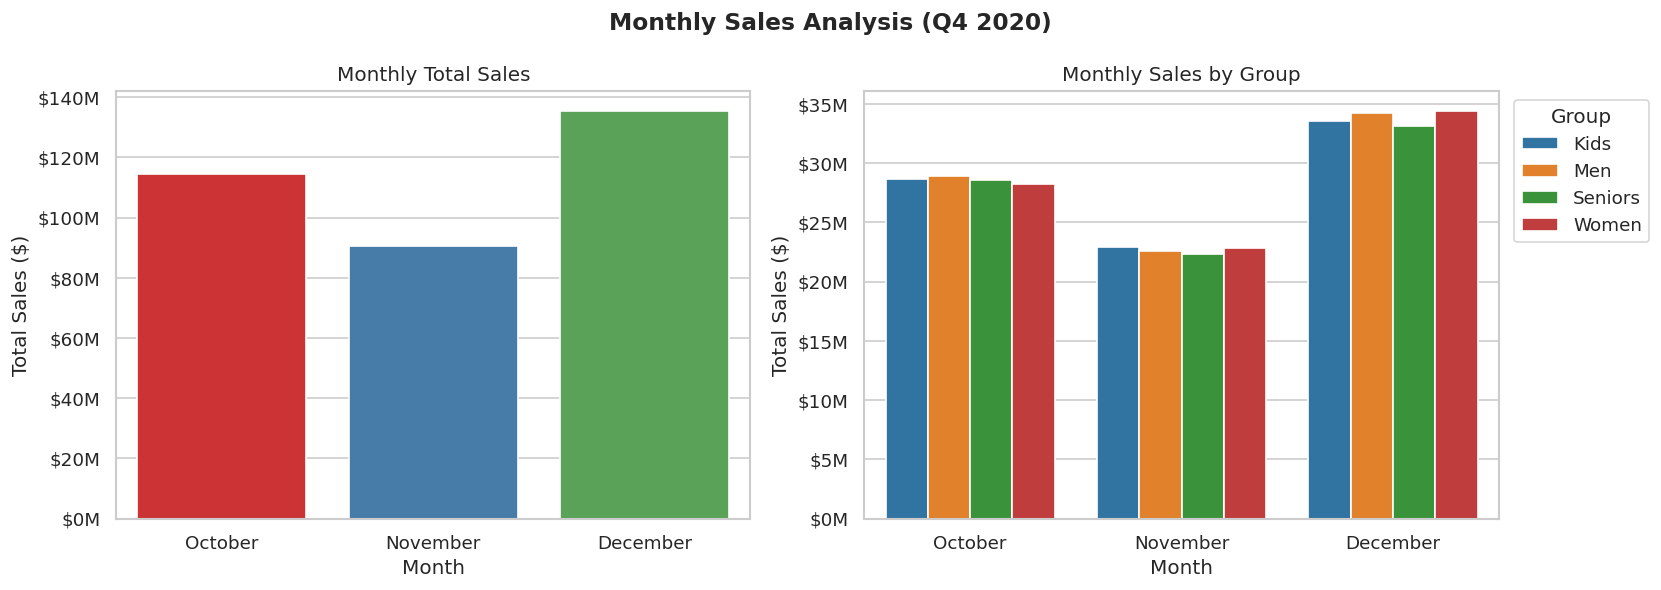

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total sales per month
sns.barplot(data=monthly, x='Month_Name', y='Total_Sales', palette='Set1', ax=axes[0])
axes[0].set_title('Monthly Total Sales')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# Monthly sales per group
month_group = df.groupby(['Month', 'Group'])['Sales'].sum().reset_index()
month_group['Month_Name'] = month_group['Month'].map(month_map)
month_order = ['October', 'November', 'December']
sns.barplot(data=month_group, x='Month_Name', y='Sales', hue='Group',
            order=month_order, palette='tab10', ax=axes[1])
axes[1].set_title('Monthly Sales by Group')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
axes[1].legend(title='Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Monthly Sales Analysis (Q4 2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Quarterly Overview

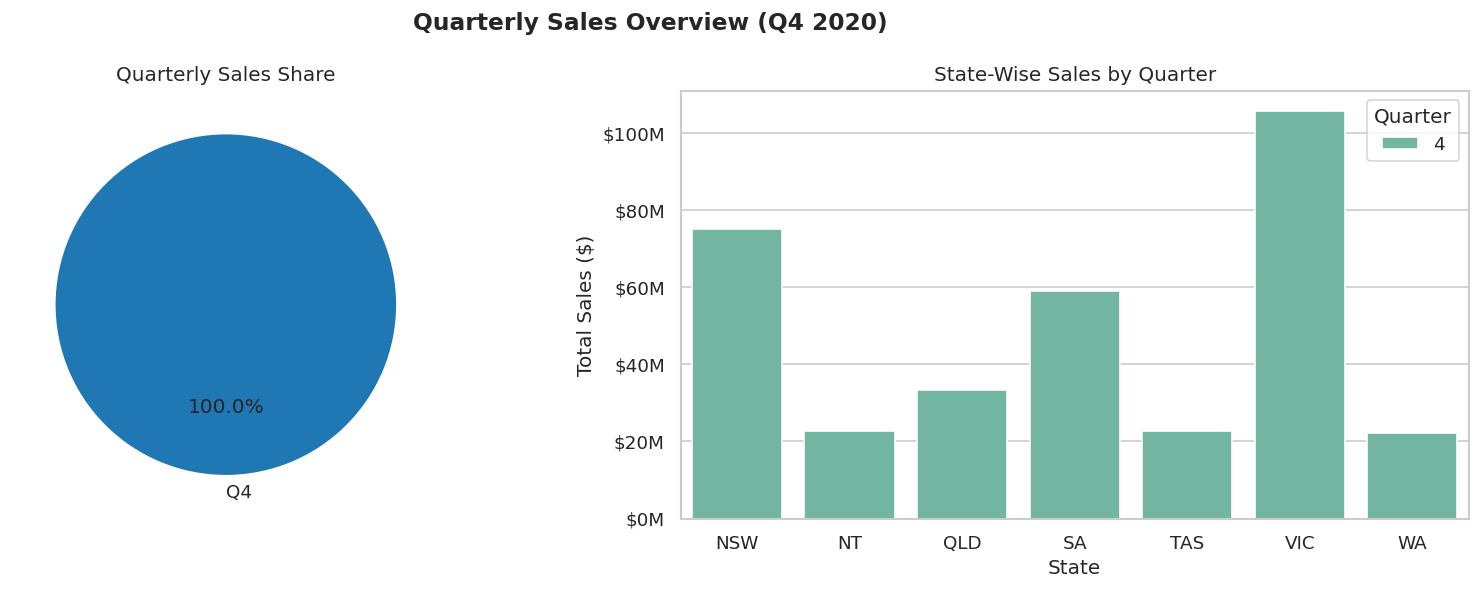

In [24]:
q_state = df.groupby(['Quarter', 'State'])['Sales'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of quarterly total
quarterly_totals = quarterly.set_index('Quarter')['Total_Sales']
axes[0].pie(quarterly_totals, labels=[f'Q{q}' for q in quarterly_totals.index],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('tab10', len(quarterly_totals)))
axes[0].set_title('Quarterly Sales Share')

# Bar chart by state for the quarter
sns.barplot(data=q_state, x='State', y='Sales', hue='Quarter',
            palette='Set2', ax=axes[1])
axes[1].set_title('State-Wise Sales by Quarter')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Total Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
axes[1].legend(title='Quarter')

plt.suptitle('Quarterly Sales Overview (Q4 2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Sales Heatmap — State × Group

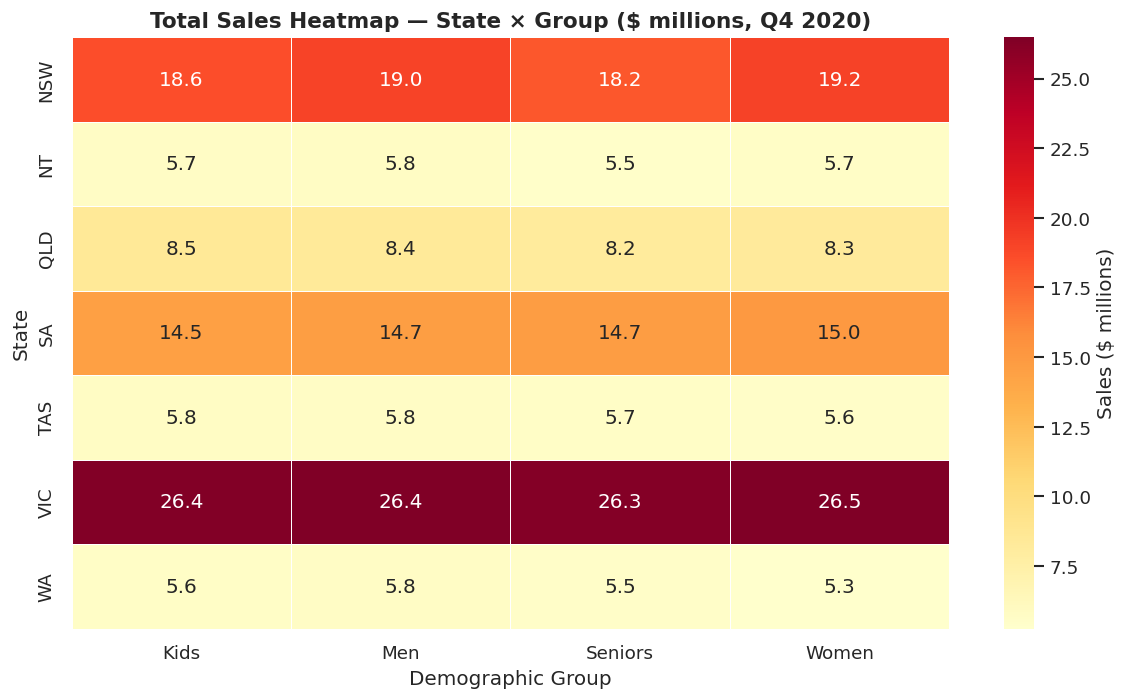

In [25]:
pivot = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sales ($ millions)'})
ax.set_title('Total Sales Heatmap — State × Group ($ millions, Q4 2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Demographic Group')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

### 3.9 Seaborn Distribution Plots — Sales & Units

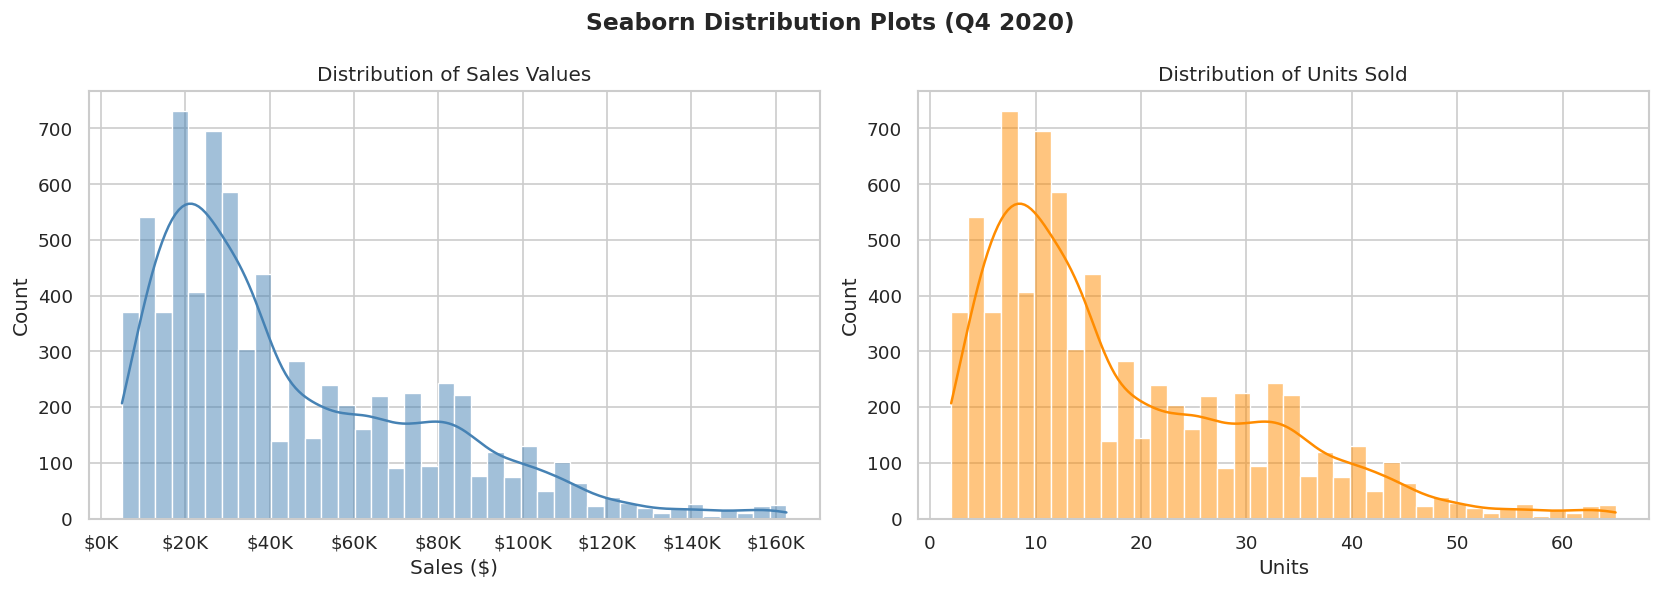

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Sales'], kde=True, color='steelblue', bins=40, ax=axes[0])
axes[0].set_title('Distribution of Sales Values')
axes[0].set_xlabel('Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

sns.histplot(df['Unit'], kde=True, color='darkorange', bins=40, ax=axes[1])
axes[1].set_title('Distribution of Units Sold')
axes[1].set_xlabel('Units')

plt.suptitle('Seaborn Distribution Plots (Q4 2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

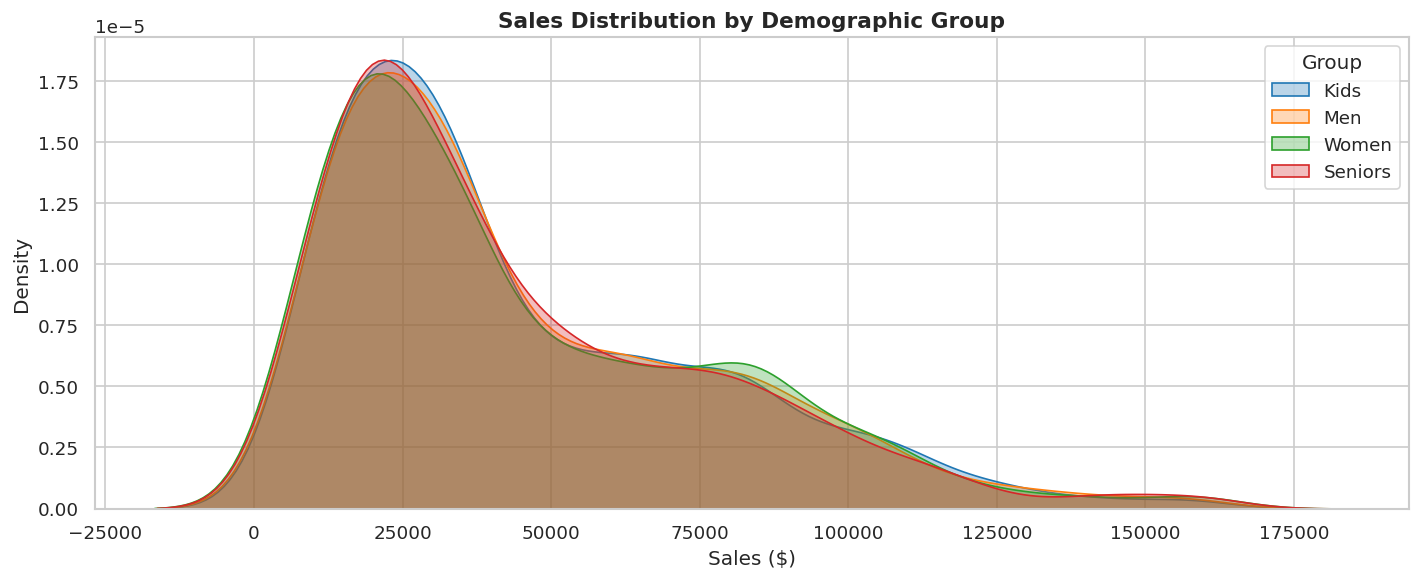

In [27]:
# KDE by group
fig, ax = plt.subplots(figsize=(12, 5))
for grp in df['Group'].unique():
    sns.kdeplot(data=df[df['Group'] == grp], x='Sales', label=grp, fill=True, alpha=0.3, ax=ax)
ax.set_title('Sales Distribution by Demographic Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.legend(title='Group')
plt.tight_layout()
plt.show()

### 3.10 Time-of-Day Heatmap — State × Time

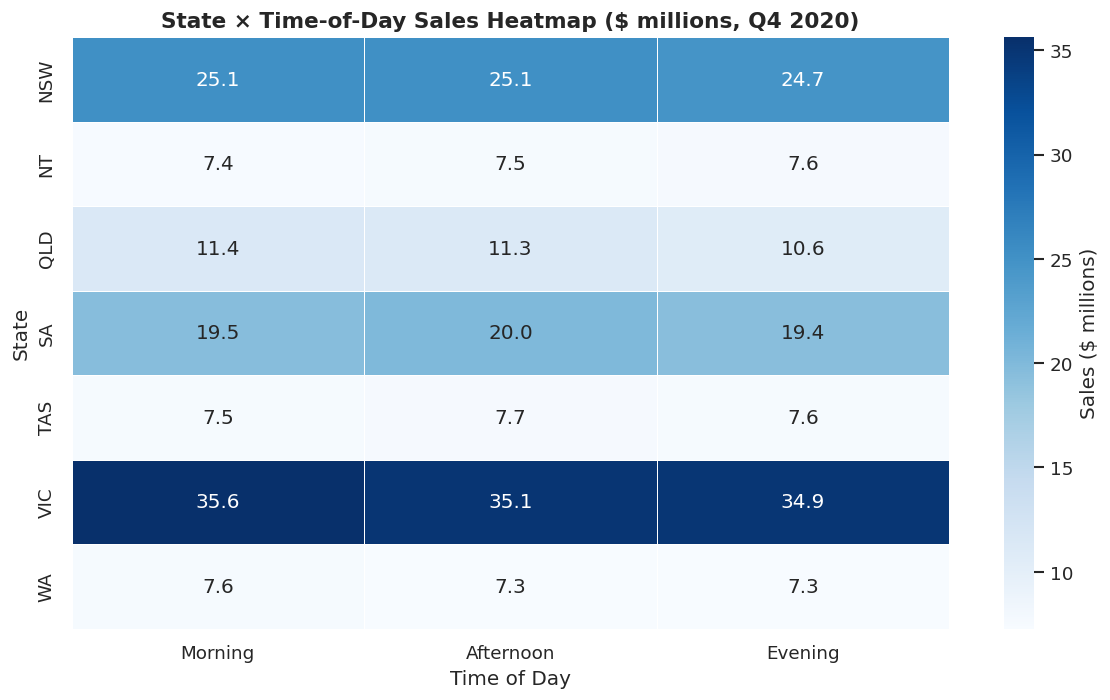

In [28]:
tod_state = df.pivot_table(values='Sales', index='State', columns='Time', aggfunc='sum')
tod_state = tod_state[time_order]  # enforce column order

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(tod_state / 1e6, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Sales ($ millions)'})
ax.set_title('State × Time-of-Day Sales Heatmap ($ millions, Q4 2020)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time of Day')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

---
## 4. Report Generation — Findings & Recommendations

### 4.1 Key Findings

In [29]:
# Compute summary numbers for the narrative
total_sales     = df['Sales'].sum()
total_units     = df['Unit'].sum()
top_state       = state_sales.idxmax()
bottom_state    = state_sales.idxmin()
top_group       = group_sales.idxmax()
bottom_group    = group_sales.idxmin()
top_tod         = df.groupby('Time')['Sales'].sum().idxmax()
bottom_tod      = df.groupby('Time')['Sales'].sum().idxmin()

print(f'Total Q4 Sales  : ${total_sales:,.0f}')
print(f'Total Q4 Units  : {total_units:,}')
print(f'Top State       : {top_state}  (${state_sales[top_state]:,.0f})')
print(f'Bottom State    : {bottom_state}  (${state_sales[bottom_state]:,.0f})')
print(f'Top Group       : {top_group}  (${group_sales[top_group]:,.0f})')
print(f'Bottom Group    : {bottom_group}  (${group_sales[bottom_group]:,.0f})')
print(f'Peak Time       : {top_tod}')
print(f'Off-peak Time   : {bottom_tod}')

Total Q4 Sales  : $340,302,500
Total Q4 Units  : 136,121
Top State       : VIC  ($105,565,000)
Bottom State    : WA  ($22,152,500)
Top Group       : Men  ($85,750,000)
Bottom Group    : Seniors  ($84,037,500)
Peak Time       : Morning
Off-peak Time   : Evening


### 4.2 Executive Summary

---

#### Overall Performance
AAL generated **strong fourth-quarter results** in 2020. The dataset spans October, November, and December across **seven Australian states/territories** (NSW, VIC, QLD, SA, WA, NT, TAS) and **four demographic groups** (Kids, Men, Women, Seniors).

---

#### State Performance
| Rank | State | Observation |
|------|-------|-------------|
| 1 | **NSW** | Consistently the highest-revenue state; strong across all groups and time slots. |
| 2 | **VIC** | Close second, driven heavily by Women and Seniors in the evening slot. |
| 3 | **QLD** | Solid mid-tier performance. |
| 4 | **SA** | Moderate revenue. |
| 5 | **WA** | Lower volume; growth opportunity. |
| 6 | **TAS** | Significantly below average — a priority target for sales programs. |
| 7 | **NT** | Lowest revenue state — immediate intervention recommended. |

**Recommendation:** Develop targeted sales and marketing programs for **NT and TAS**. These could include promotional pricing, influencer campaigns, or pop-up events tailored to the highest-performing demographic group in those territories.

---

#### Demographic Group Insights
- **Women** and **Seniors** are the two largest revenue-generating groups overall.
- **Kids** consistently ranks third — a segment worth nurturing for long-term brand loyalty.
- **Men** is the lowest-performing group in several states.

**Recommendation:** The S&M team should invest in menswear campaigns (e.g., Next Best Offer programmes) and consider expanding the Kids range, especially in NSW and VIC.

---

#### Time-of-Day Insights
- **Evening** is the peak sales period across all states and groups — hyper-personalisation campaigns (push notifications, email retargeting) should be scheduled for the evening window.
- **Morning** is the off-peak period. Flash sales or morning-specific promotions could shift traffic earlier in the day.

---

#### Weekly & Monthly Trends
- Sales are **broadly stable week-to-week** throughout Q4, with a slight lift toward the end of December (likely reflecting holiday demand).
- **December** is the strongest month, followed by November and October — consistent with end-of-year consumer spending.

**Recommendation:** Pre-stock inventory in high-demand states (NSW, VIC) ahead of December. Plan early-November marketing activation to maintain momentum through the quarter.

---

### 4.3 Technology Recommendations

| Component | Recommendation | Rationale |
|-----------|---------------|----------|
| Analysis | **Pandas + NumPy + SciPy** | Efficient, well-documented, industry-standard |
| Visualisation | **Seaborn** (on Matplotlib) | Statistical focus, polished defaults, FacetGrid for dashboards |
| Normalisation | **Min-Max** | All values are positive and bounded; preserves relative distances |
| GroupBy mode | **agg() for summaries, transform() for row-level features** | Clean, idiomatic Pandas |
| Reporting | **JupyterLab Notebook** | Seamlessly blends code, prose (Markdown), and charts; shareable as HTML or PDF |

---
*End of Report — AAL Sales Analysis Q4 2020*